# TP Final - Aprendizaje por refuerzo
- Autor: Juan Cruz Piñero
 - Docente: Miguel Augusto Azar
  - Carrera: Carrera de Especializacion en Inteligencia Artificial. Universidad de Buenos Aires

En este trabajo abordare la resolucion de un problema de optimizacion de politica de un Agente de aprendizaje mediante el uso de Q-Learning , para así analizar cómo se comportan  los agentes en el entorno elegido.

El entorno elegido es 'Taxi' utilizando la biblioteca Gymnasium. 


Se toma como base el script provisto por el docente en la clase .




### Entorno
#### Descripción del entorno
El entorno elegido es el 'Taxi-v3' de la biblioteca Gymnasium.

El entorno del Taxi es un problema de grilla discreto. Hay un taxi, que es el único agente. El mundo es una cuadrícula de 5x5 que contiene cuatro ubicaciones especiales etiquetadas como R (rojo), G (verde), Y (amarillo) y B (azul). Estas representan posibles lugares de recogida y entrega de pasajeros.

El objetivo es levantar al pasajero en una de estas cuatro ubicaciones y dejarlo en otra. El taxi puede realizar seis acciones deterministas. Una vez que el pasajero es dejado en el destino, el episodio termina.

#### Espacio de acciones
El espacio de acciones es discreto con 6 acciones disponibles:

- 0: mover hacia el sur
- 1: mover hacia el norte
- 2: mover hacia el este
- 3: mover hacia el oeste
- 4: recoger al pasajero
- 5: dejar al pasajero

#### Espacio de estados
El espacio de estados también es discreto con 500 estados posibles. Estos 500 estados representan todas las combinaciones posibles de:

- La ubicación de la fila del taxi (5 posibles valores)
- La ubicación de la columna del taxi (5 posibles valores)
- La ubicación del pasajero (5 posibles valores: 4 ubicaciones de recogida/entrega + 1 estado "en el taxi")
- La ubicación del destino (4 posibles valores)

Hay **500 estados discretos** ya que existen 25 posiciones posibles para el taxi, 5 posibles ubicaciones del pasajero (incluyendo el caso en que el pasajero está en el taxi) y 4 ubicaciones de destino.

Las ubicaciones de destino en el mapa se representan con la primera letra del color.

**Ubicaciones del Pasajero:**

* 0: Rojo
* 1: Verde
* 2: Amarillo
* 3: Azul
* 4: En el taxi

**Destinos:**

* 0: Rojo
* 1: Verde
* 2: Amarillo
* 3: Azul

Una observación se devuelve como un `int()` que codifica el estado correspondiente, calculado por:

((fila_taxi * 5 + columna_taxi) * 5 + ubicación_pasajero) * 4 + destino

#### Estado de Inicio (Starting State):

El estado inicial se muestrea uniformemente de los estados posibles donde el pasajero no está en su destino ni dentro del taxi. Hay 300 posibles estados iniciales: 25 posiciones del taxi, 4 ubicaciones del pasajero (excluyendo dentro del taxi) y 3 destinos (excluyendo la ubicación actual del pasajero).

#### Recompensas (Rewards):

* -1 por paso a menos que se active otra recompensa.
* +20 por entregar al pasajero.
* -10 por ejecutar acciones de "recoger" y "dejar" ilegalmente.

Una acción que resulta en un no-op, como moverse contra una pared, incurrirá en la penalización del paso de tiempo. Los no-ops se pueden evitar muestreando la `action_mask` devuelta en `info`.

#### Finalización del Episodio (Episode End):

El episodio termina si ocurre lo siguiente:

**Terminación:**
1.  El taxi deja al pasajero.

**Truncamiento (al usar el wrapper `time_limit`):**
1.  La duración del episodio es de 200 pasos.


#### Definicion  de parametros del entorno

In [100]:

# --- Parámetros ---
env_name = "Taxi-v3"
max_steps_per_episode = 100
learning_rate = 0.1
discount_factor = 0.95
num_episodes = 15000  # Reducido para un ejemplo más rápido
epsilon_start = 1.0
min_epsilon = 0.01
epsilon_decay_rate = 0.0005
report_interval = num_episodes // 10
moving_avg_window = 100

#### Inicializacion del entorno

In [101]:
from utils import demonstrate_policy, train_q_learning_agent
import gymnasium as gym
import numpy as np



# --- Inicialización del Entorno ---
env = gym.make(
    env_name,
    max_episode_steps=max_steps_per_episode,
    # render_mode="human"
)

n_states = env.observation_space.n
n_actions = env.action_space.n

print('Estados:', n_states)
print('Acciones:', n_actions)

q_table = np.zeros((n_states, n_actions))





Estados: 500
Acciones: 6


#### Entrenamiento Q-Learning



In [102]:
# --- Entrenamiento del Agente ---
trained_q_table, rewards_all_episodes, steps_all_episodes = train_q_learning_agent(
    env, q_table, learning_rate, discount_factor, num_episodes,
    epsilon_start, min_epsilon, epsilon_decay_rate,
    report_interval
)

env.close()

--- Iniciando Entrenamiento Q-Learning del Agente ---
Entorno: Taxi-v3
Parámetros: α=0.1, γ=0.95, ε-decay=0.0005
Episodios: 15000
----------------------------------------
Episodio:  1500/15000 | Tasa Éxito (últimos 1500):   0.47% | Pasos Prom (últimos 1500):   81.7 | Epsilon: 0.478
Episodio:  3000/15000 | Tasa Éxito (últimos 1500):  16.27% | Pasos Prom (últimos 1500):   24.5 | Epsilon: 0.231
Episodio:  4500/15000 | Tasa Éxito (últimos 1500):  46.33% | Pasos Prom (últimos 1500):   16.1 | Epsilon: 0.114
Episodio:  6000/15000 | Tasa Éxito (últimos 1500):  70.60% | Pasos Prom (últimos 1500):   14.4 | Epsilon: 0.059
Episodio:  7500/15000 | Tasa Éxito (últimos 1500):  85.07% | Pasos Prom (últimos 1500):   13.8 | Epsilon: 0.033
Episodio:  9000/15000 | Tasa Éxito (últimos 1500):  90.27% | Pasos Prom (últimos 1500):   13.3 | Epsilon: 0.021
Episodio: 10500/15000 | Tasa Éxito (últimos 1500):  94.07% | Pasos Prom (últimos 1500):   13.5 | Epsilon: 0.015
Episodio: 12000/15000 | Tasa Éxito (últimos 1

### Visualizacion de resultados

Podemos ver la Tabla Q Final, aunque al ser tan grande no nos dice mucho. Por otro lado, los estados estan codificados con lo cual no existe una interpretacion directa ni analogia con el mapa.



In [103]:
# --- Visualización de Resultados ---
print("\n Dimensión de Tabla Q Final:",trained_q_table.shape)
np.set_printoptions(precision=3, suppress=True)
print(trained_q_table)


 Dimensión de Tabla Q Final: (500, 6)
[[  0.      0.      0.      0.      0.      0.   ]
 [  0.798   2.258  -0.086   2.161   5.21   -6.547]
 [  6.001   8.156   6.683   7.35   10.951  -0.934]
 ...
 [  1.431  12.572   4.817   1.062  -3.403  -5.246]
 [ -2.995  -2.455  -2.295   5.263  -9.491 -10.795]
 [  7.911   9.294   9.256  18.     -2.037   3.093]]



Para ver si el agente aprendio visualizamos la evolucion de la tasa de éxito a lo largo de los episodios.

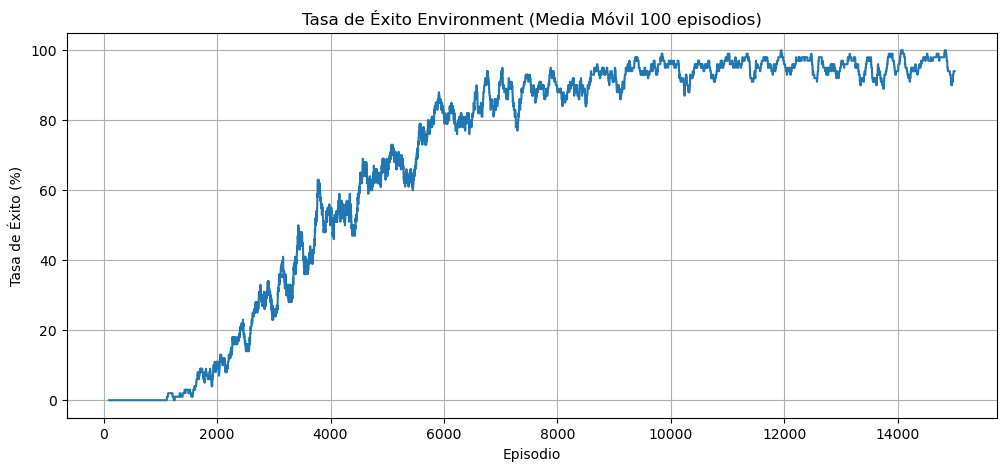

In [104]:
from utils import plot_success_rate

plot_success_rate(rewards_all_episodes, num_episodes, moving_avg_window)


Finalmente visualizamos la politica aprendida por el agente fijanddo un estado inicial de el pasajero y el destino del pasajero.

In [105]:
# import gymnasium as gym
# import numpy as np
# import gymnasium as gym
# import numpy as np
# 
# print("Representación del entorno Taxi-v3 (env.desc):")
# for row in env.desc:
#     print("".join([char.decode('utf-8') for char in row]))
# env.close()


Representación del entorno Taxi-v3 (env.desc):
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Representación del entorno Taxi-v3 (env.desc):
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

In [106]:
import utils
import importlib
importlib.reload(utils)
from utils import get_preferred_action
passenger_loc = 4  # Rojo =0 Green=1 , Yellow=2 , Blue=3, 4=en el taxi
dest_loc = 3       # Azul
get_preferred_action(trained_q_table,3,2 , passenger_loc,dest_loc)

'↓'

En esta representacion deberiamos ver que el agente aprendio a tomar la accion de ir a la derecha si es que se encuentra en la fila 0 columna 1, y el pasajero va desde arriba del taxi hacia Azul (B). Lo cual resulta logico.

In [107]:

demonstrate_policy(env_name, trained_q_table, num_episodes=1, render=True, delay=0.5)


Episodio de Demostración 1:
Episodio terminado después de 10 pasos con recompensa: 11


### Variacion de hiperparametros

Veamos como cambia el entrenamiento y los resultados cuando cambiamos los siguientes parametros:

#### Disminucion de learning rate


In [129]:
learning_rate = 0.1 # multiplicamos por 2
discount_factor = 0.95 # aumentamos discount para que tengan mayor peso acciones pasadas
num_episodes = 15000  # 
epsilon_start = 1.0
min_epsilon = 0.01
epsilon_decay_rate = 0.0005

In [130]:
# volvemos a crear otro env y entrenarlo
env = gym.make(
    env_name,
    max_episode_steps=max_steps_per_episode,
    # render_mode="human"
)
q_table = np.zeros((n_states, n_actions))

trained_q_table_2, rewards_all_episodes_2, steps_all_episodes_2 = train_q_learning_agent(
    env, q_table, learning_rate, discount_factor, num_episodes,
    epsilon_start, min_epsilon, epsilon_decay_rate,
    report_interval
)
env.close()

--- Iniciando Entrenamiento Q-Learning del Agente ---
Entorno: Taxi-v3
Parámetros: α=0.01, γ=0.98, ε-decay=0.0005
Episodios: 15000
----------------------------------------
Episodio:  1500/15000 | Tasa Éxito (últimos 1500):   0.07% | Pasos Prom (últimos 1500):   98.4 | Epsilon: 0.478
Episodio:  3000/15000 | Tasa Éxito (últimos 1500):   0.27% | Pasos Prom (últimos 1500):   94.0 | Epsilon: 0.231
Episodio:  4500/15000 | Tasa Éxito (últimos 1500):   1.33% | Pasos Prom (últimos 1500):   86.3 | Epsilon: 0.114
Episodio:  6000/15000 | Tasa Éxito (últimos 1500):   7.00% | Pasos Prom (últimos 1500):   73.9 | Epsilon: 0.059
Episodio:  7500/15000 | Tasa Éxito (últimos 1500):  14.80% | Pasos Prom (últimos 1500):   61.3 | Epsilon: 0.033
Episodio:  9000/15000 | Tasa Éxito (últimos 1500):  24.67% | Pasos Prom (últimos 1500):   49.0 | Epsilon: 0.021
Episodio: 10500/15000 | Tasa Éxito (últimos 1500):  38.00% | Pasos Prom (últimos 1500):   36.6 | Epsilon: 0.015
Episodio: 12000/15000 | Tasa Éxito (últimos 

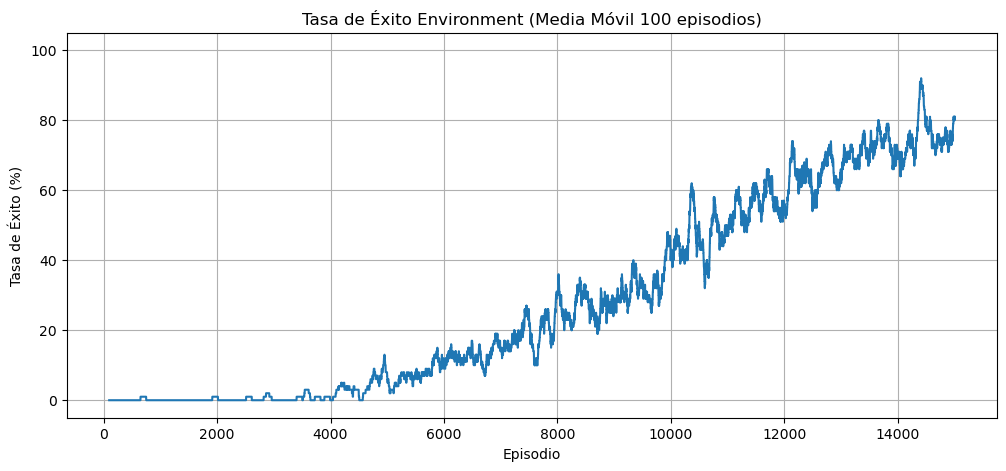

In [131]:
plot_success_rate(rewards_all_episodes_2, num_episodes, moving_avg_window)


In [111]:
import utils
import importlib
importlib.reload(utils)
from utils import get_preferred_action
passenger_loc = 4  # Rojo =0 Green=1 , Yellow=2 , Blue=3, 4=en el taxi
dest_loc = 3       # Azul
get_preferred_action(trained_q_table_2,3,2 , passenger_loc,dest_loc)

'↓'

In [112]:
# --- Visualización de Resultados ---
print("\n Dimensión de Tabla Q Final:",trained_q_table_2.shape)
np.set_printoptions(precision=3, suppress=True)
print(trained_q_table_2)


 Dimensión de Tabla Q Final: (500, 6)
[[ 0.     0.     0.     0.     0.     0.   ]
 [ 5.99   7.183  5.976  7.193  8.362 -1.961]
 [10.766 12.002 10.727 12.006 13.274  3.003]
 ...
 [-1.464 14.558  1.467  4.313 -7.059 -1.982]
 [ 2.802  9.537  1.768  1.438 -6.508 -5.47 ]
 [15.553 15.542 15.123 18.6    7.719  7.492]]


In [113]:
demonstrate_policy(env_name, trained_q_table_2, num_episodes=1, render=True, delay=0.5)



Episodio de Demostración 1:
Episodio terminado después de 17 pasos con recompensa: 4


#### Experimento 3 - aumentamos el min_epsilon para que el agente siempre explore



--- Iniciando Entrenamiento Q-Learning del Agente ---
Entorno: Taxi-v3
Parámetros: α=0.1, γ=0.98, ε-decay=0.0005
Episodios: 15000
----------------------------------------
Episodio:  1500/15000 | Tasa Éxito (últimos 1500):   0.13% | Pasos Prom (últimos 1500):   89.6 | Epsilon: 0.684
Episodio:  3000/15000 | Tasa Éxito (últimos 1500):   1.40% | Pasos Prom (últimos 1500):   41.7 | Epsilon: 0.534
Episodio:  4500/15000 | Tasa Éxito (últimos 1500):   2.93% | Pasos Prom (últimos 1500):   28.6 | Epsilon: 0.463
Episodio:  6000/15000 | Tasa Éxito (últimos 1500):   7.27% | Pasos Prom (últimos 1500):   25.6 | Epsilon: 0.430
Episodio:  7500/15000 | Tasa Éxito (últimos 1500):   7.73% | Pasos Prom (últimos 1500):   24.4 | Epsilon: 0.414
Episodio:  9000/15000 | Tasa Éxito (últimos 1500):   8.40% | Pasos Prom (últimos 1500):   24.1 | Epsilon: 0.407
Episodio: 10500/15000 | Tasa Éxito (últimos 1500):   9.00% | Pasos Prom (últimos 1500):   23.3 | Epsilon: 0.403
Episodio: 12000/15000 | Tasa Éxito (últimos 1

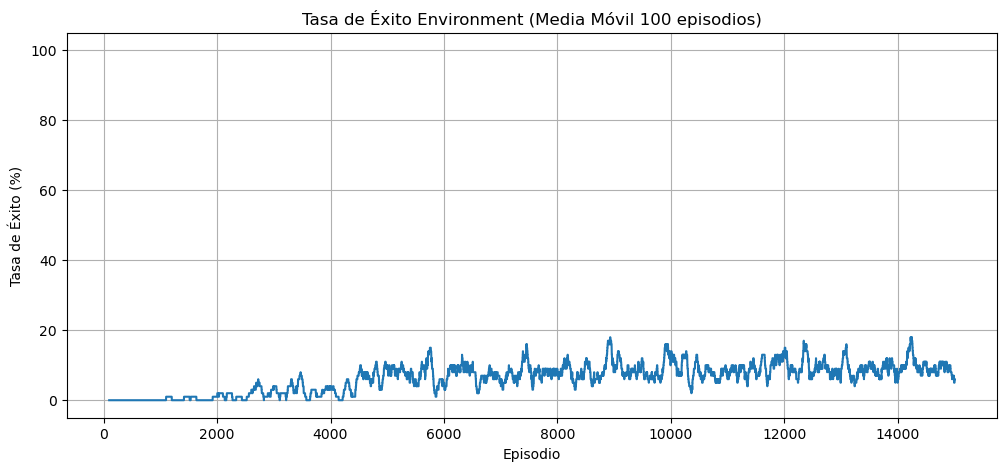

In [132]:
learning_rate = 0.1 #
discount_factor = 0.95 # 
num_episodes = 15000  # 10 veces mas episodios
epsilon_start = 1.0
min_epsilon = 0.4 # aumentamos el min_epsilon
epsilon_decay_rate = 0.0005

# volvemos a crear otro env y entrenarlo
env = gym.make(
    env_name,
    max_episode_steps=max_steps_per_episode,
    # render_mode="human"
)
q_table = np.zeros((n_states, n_actions))

trained_q_table_2, rewards_all_episodes_2, steps_all_episodes_2 = train_q_learning_agent(
    env, q_table, learning_rate, discount_factor, num_episodes,
    epsilon_start, min_epsilon, epsilon_decay_rate,
    report_interval
)
env.close()
plot_success_rate(rewards_all_episodes_2, num_episodes, moving_avg_window)


#### Experimento 4 - disminucion del discount_factor para que el agente le de menos peso a las recompensas pasadas 

--- Iniciando Entrenamiento Q-Learning del Agente ---
Entorno: Taxi-v3
Parámetros: α=0.1, γ=0.02, ε-decay=0.0005
Episodios: 15000
----------------------------------------
Episodio:  1500/15000 | Tasa Éxito (últimos 1500):   0.00% | Pasos Prom (últimos 1500):   99.1 | Epsilon: 0.478
Episodio:  3000/15000 | Tasa Éxito (últimos 1500):   0.20% | Pasos Prom (últimos 1500):   97.0 | Epsilon: 0.231
Episodio:  4500/15000 | Tasa Éxito (últimos 1500):   1.67% | Pasos Prom (últimos 1500):   90.3 | Epsilon: 0.114
Episodio:  6000/15000 | Tasa Éxito (últimos 1500):   6.93% | Pasos Prom (últimos 1500):   79.4 | Epsilon: 0.059
Episodio:  7500/15000 | Tasa Éxito (últimos 1500):  15.47% | Pasos Prom (últimos 1500):   74.9 | Epsilon: 0.033
Episodio:  9000/15000 | Tasa Éxito (últimos 1500):  21.73% | Pasos Prom (últimos 1500):   74.3 | Epsilon: 0.021
Episodio: 10500/15000 | Tasa Éxito (últimos 1500):  26.20% | Pasos Prom (últimos 1500):   73.5 | Epsilon: 0.015
Episodio: 12000/15000 | Tasa Éxito (últimos 1

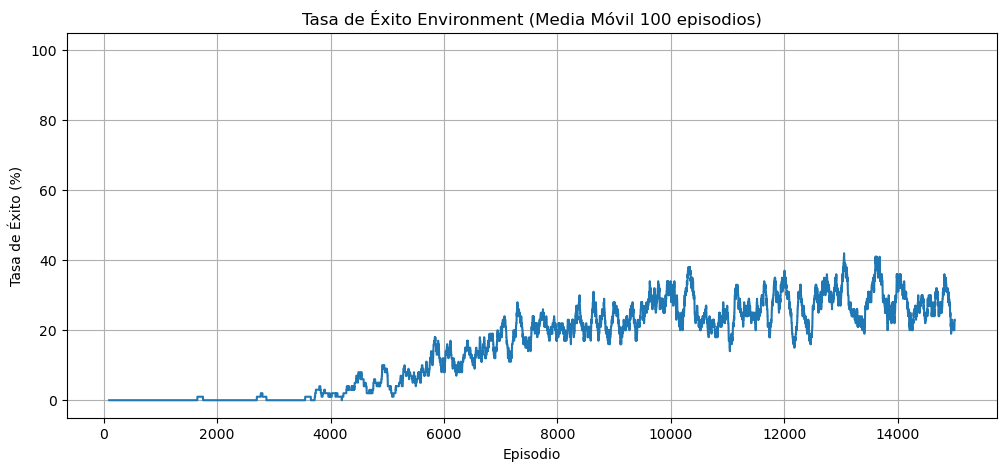

In [134]:
learning_rate = 0.1 #
discount_factor = 0.02 # 
num_episodes = 15000  # 10 veces mas episodios
epsilon_start = 1.0
min_epsilon = 0.01 
epsilon_decay_rate = 0.0005

# volvemos a crear otro env y entrenarlo
env = gym.make(
    env_name,
    max_episode_steps=max_steps_per_episode,
    # render_mode="human"
)
q_table = np.zeros((n_states, n_actions))

trained_q_table_2, rewards_all_episodes_2, steps_all_episodes_2 = train_q_learning_agent(
    env, q_table, learning_rate, discount_factor, num_episodes,
    epsilon_start, min_epsilon, epsilon_decay_rate,
    report_interval
)
env.close()
plot_success_rate(rewards_all_episodes_2, num_episodes, moving_avg_window)


### Conclusiones
De los resultados de los dos experimentos podemos ver que :
- A partir del episodio 8000 aproximadamente (con la primera configuracion de parametros),  el agente ya logra tener exito en prácticamente todos los episodios.
- El learning rate demasiado chico hace que se necesiten mas episodios par alcanzar una buena tasa de exito.
- aumentar demasiado el min epsilon hace que el agente se explore demasiado, por lo tanto tambien retrasa /imposibilita el aprendizaje.
- El discount factor demasiado chico tambien retrasa  el aprendizaje (o incluso podria imposibilitarlo).. en este caso pq se necesita tener en cuenta varios pasos para resolver este problema.